# 01 · EDA de negocio — Optimización de proveedores médicos

## Objetivo

El objetivo del proyecto es **reducir el coste de los servicios médicos** mediante una mejor asignación de proveedores, sin deteriorar la calidad y considerando posteriormente restricciones de capacidad y diversificación.

Este notebook responde una pregunta previa al modelado:

> **¿Dónde existe realmente capacidad de decisión y oportunidad económica?**

La unidad de análisis de mercado será **Tratamiento + Ciudad**. Dos proveedores solo son alternativas comparables cuando pueden atender el mismo tratamiento dentro de la misma ciudad.

### Alcance de este notebook

1. Validar la calidad e integridad del histórico.
2. Cuantificar volumen, proveedores, tratamientos y ciudades.
3. Identificar mercados con alternativas reales de proveedor.
4. Medir cuánto volumen y gasto se concentra en dichos mercados.
5. Analizar la dispersión histórica de costes entre proveedores comparables.
6. Evaluar la robustez de esas diferencias cuando existe evidencia histórica suficiente.

**Importante:** las brechas históricas de coste **no se interpretan como ahorro potencial**. El ahorro se estimará más adelante con baremos actuales, calidad, capacidad y restricciones de asignación.

## 1. Descripción del dataset

| Campo | Descripción |
|---|---|
| `IDEPREADMIN` | Identificador de la prestación o servicio administrado. |
| `NUMLIQUID` | Número de liquidación asociado a la prestación. |
| `CODIGO_TRATAMIENTO` | Código del tratamiento realizado. |
| `DESCPROCED` | Descripción del tratamiento. |
| `ID_PROVEEDOR` | Identificador único del proveedor. |
| `CODPROVEEDOR` | Código interno del proveedor. |
| `NOMBREPROVEEDOR` | Nombre o razón social del proveedor. |
| `TIPOPREADMIN` | Código del tipo de servicio. |
| `DESCRIPTIPOPRE` | Descripción del tipo de servicio. |
| `CODIGO_MUNICIPIO` | Código del municipio. |
| `DESCMUNICIPIO` | Nombre del municipio. |
| `SUMA` | Coste histórico del servicio. |

### Reglas maestras validadas

- La llave única del servicio es `IDEPREADMIN + NUMLIQUID + CODIGO_TRATAMIENTO`.
- `ID_PROVEEDOR` y `CODPROVEEDOR` presentan una relación 1:1.
- Cada proveedor está asociado a un único municipio en este histórico.
- Cada `CODIGO_TRATAMIENTO` tiene una única descripción.
- Cada `CODPROVEEDOR` tiene un único nombre.
- El análisis de coste debe hacerse dentro de grupos comparables, no mediante extremos globales.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Compatible con Google Colab y con ejecución local.
candidatos = [
    Path("/content/datos tratramiento detalleV4.xlsx"),
    Path("/mnt/data/datos tratramiento detalleV4.xlsx"),
    Path("datos tratramiento detalleV4.xlsx"),
]

DATA_PATH = next((p for p in candidatos if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró 'datos tratramiento detalleV4.xlsx'. "
        "Cárgalo en Colab o ajusta DATA_PATH."
    )

df = pd.read_excel(DATA_PATH)

print(f"Archivo: {DATA_PATH}")
print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]:,}")
display(df.head())

Archivo: /mnt/data/datos tratramiento detalleV4.xlsx
Filas: 72,391
Columnas: 15


,IDEPREADMIN,NUMLIQUID,CODIGO_TRATAMIENTO,DESCPROCED,TIPOIDBENEFSIN,NUMIDBENEFSIN,DVIDBENEFSIN,ID_PROVEEDOR,CODPROVEEDOR,NOMBREPROVEEDOR,TIPOPREADMIN,DESCRIPTIPOPRE,CODIGO_MUNICIPIO,DESCMUNICIPIO,SUMA
0,3530764,1,401140014,PERFIL LIPIDICO,J,30197846,3,J-30197846-3,28444,CLINICA CORAZON DE JESUS C.A.,4,MEDICINA PREVENTIVA,023-033-009,LAGUNILLAS,49.86
1,3530764,0,109010001,MEDICINA INTERNA CONSULTA 1A VEZ,J,30522136,7,J-30522136-7,20090,SERVICIOS MEDICOS COLON C.A,4,MEDICINA PREVENTIVA,023-033-009,LAGUNILLAS,25.00
2,3530931,1,403091002,PRUEBA DE ESFUERZO,J,30522136,7,J-30522136-7,20090,SERVICIOS MEDICOS COLON C.A,4,MEDICINA PREVENTIVA,023-033-009,LAGUNILLAS,194.99
3,3534226,0,115010001,TRAUMATOLOGIA Y ORTOPEDIA CONSULTA 1A VEZ,J,30522136,7,J-30522136-7,20090,SERVICIOS MEDICOS COLON C.A,4,MEDICINA PREVENTIVA,023-033-009,LAGUNILLAS,25.00
4,3541280,0,404030412,CITOLOGIA GINECOLOGICA,J,30522136,7,J-30522136-7,20090,SERVICIOS MEDICOS COLON C.A,4,MEDICINA PREVENTIVA,023-033-009,LAGUNILLAS,66.56


## 2. Validación de integridad

In [2]:
# Llave única del servicio
llave_servicio = ["IDEPREADMIN", "NUMLIQUID", "CODIGO_TRATAMIENTO"]

duplicados = df.duplicated(subset=llave_servicio, keep=False).sum()

# Dependencias maestras
id_a_codigo = df.groupby("ID_PROVEEDOR")["CODPROVEEDOR"].nunique()
codigo_a_id = df.groupby("CODPROVEEDOR")["ID_PROVEEDOR"].nunique()
proveedor_municipio = df.groupby("CODPROVEEDOR")["CODIGO_MUNICIPIO"].nunique()
tratamiento_desc = df.groupby("CODIGO_TRATAMIENTO")["DESCPROCED"].nunique()
tipo_desc = df.groupby("TIPOPREADMIN")["DESCRIPTIPOPRE"].nunique()

validaciones = pd.DataFrame({
    "VALIDACION": [
        "Filas",
        "Servicios únicos",
        "Llaves duplicadas",
        "Proveedores",
        "ID_PROVEEDOR con varios CODPROVEEDOR",
        "CODPROVEEDOR con varios ID_PROVEEDOR",
        "Proveedores asociados a >1 municipio",
        "Tratamientos",
        "Tratamientos con >1 descripción",
        "Tipos de servicio",
        "Tipos con >1 descripción",
        "Nulos totales",
        "Costes en cero",
        "Costes negativos",
    ],
    "VALOR": [
        len(df),
        df[llave_servicio].drop_duplicates().shape[0],
        duplicados,
        df["CODPROVEEDOR"].nunique(),
        (id_a_codigo > 1).sum(),
        (codigo_a_id > 1).sum(),
        (proveedor_municipio > 1).sum(),
        df["CODIGO_TRATAMIENTO"].nunique(),
        (tratamiento_desc > 1).sum(),
        df["TIPOPREADMIN"].nunique(),
        (tipo_desc > 1).sum(),
        int(df.isna().sum().sum()),
        int((df["SUMA"] == 0).sum()),
        int((df["SUMA"] < 0).sum()),
    ]
})

display(validaciones)

,VALIDACION,VALOR
0,Filas,72391
1,Servicios únicos,72391
2,Llaves duplicadas,0
3,Proveedores,297
4,ID_PROVEEDOR con varios CODPROVEEDOR,0
5,CODPROVEEDOR con varios ID_PROVEEDOR,0
6,Proveedores asociados a >1 municipio,0
7,Tratamientos,705
8,Tratamientos con >1 descripción,0
9,Tipos de servicio,2


### Hallazgo

El histórico presenta una estructura maestra consistente: no se detectan duplicados de la llave de servicio, las relaciones proveedor/código son coherentes y no existen nulos.

Se identifica **un único registro con coste 0**, tratado como error de la fuente. Los costes extremos globales no se eliminan: corresponden potencialmente a tratamientos de distinta severidad y deben evaluarse dentro de mercados comparables.

In [3]:
# Conservamos el original para trazabilidad.
df_raw = df.copy()

registro_costo_cero = df[df["SUMA"] == 0].copy()
display(registro_costo_cero)

df = df[df["SUMA"] > 0].copy()

print(f"Registros originales: {len(df_raw):,}")
print(f"Registros eliminados por coste 0: {len(registro_costo_cero):,}")
print(f"Registros válidos para análisis: {len(df):,}")

,IDEPREADMIN,NUMLIQUID,CODIGO_TRATAMIENTO,DESCPROCED,TIPOIDBENEFSIN,NUMIDBENEFSIN,DVIDBENEFSIN,ID_PROVEEDOR,CODPROVEEDOR,NOMBREPROVEEDOR,TIPOPREADMIN,DESCRIPTIPOPRE,CODIGO_MUNICIPIO,DESCMUNICIPIO,SUMA
71460,3604245,0,109010002,MEDICINA INTERNA CONSULTA DE CONTROL,J,50280684,9,J-50280684-9,30281,UNIDAD MEDICA ESPECIALIZADA NEUROCARE C.A,4,MEDICINA PREVENTIVA,015-020-021,ZAMORA,0.00


Registros originales: 72,391
Registros eliminados por coste 0: 1
Registros válidos para análisis: 72,390


## 3. Dimensión del histórico

In [4]:
resumen_general = pd.DataFrame({
    "INDICADOR": [
        "Servicios",
        "Proveedores",
        "Tratamientos",
        "Municipios",
        "Tipos de servicio",
        "Gasto histórico"
    ],
    "VALOR": [
        len(df),
        df["CODPROVEEDOR"].nunique(),
        df["CODIGO_TRATAMIENTO"].nunique(),
        df["CODIGO_MUNICIPIO"].nunique(),
        df["TIPOPREADMIN"].nunique(),
        df["SUMA"].sum()
    ]
})

display(resumen_general)

,INDICADOR,VALOR
0,Servicios,"72,390.00"
1,Proveedores,297.00
2,Tratamientos,705.00
3,Municipios,67.00
4,Tipos de servicio,2.00
5,Gasto histórico,"18,661,616.40"


## 4. Definición del mercado: Tratamiento + Ciudad

Analizar únicamente `CODIGO_TRATAMIENTO` puede producir una falsa sensación de competencia: un proveedor ubicado en otra ciudad no necesariamente constituye una alternativa operativa.

Por ello se define:

> **Mercado = CODIGO_TRATAMIENTO + CODIGO_MUNICIPIO**

Esta granularidad será también la utilizada posteriormente para pronosticar demanda.

In [5]:
mercados = (
    df.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "DESCPROCED",
            "CODIGO_MUNICIPIO",
            "DESCMUNICIPIO"
        ]
    )
    .agg(
        SERVICIOS=("IDEPREADMIN", "size"),
        PROVEEDORES=("CODPROVEEDOR", "nunique"),
        GASTO_TOTAL=("SUMA", "sum"),
        COSTO_MEDIANA=("SUMA", "median")
    )
    .reset_index()
)

total_mercados = len(mercados)

resumen_competencia = pd.DataFrame({
    "CRITERIO": [
        "1 proveedor",
        "2 o más proveedores",
        "3 o más proveedores",
        "5 o más proveedores",
        "10 o más proveedores",
    ],
    "MERCADOS": [
        (mercados["PROVEEDORES"] == 1).sum(),
        (mercados["PROVEEDORES"] >= 2).sum(),
        (mercados["PROVEEDORES"] >= 3).sum(),
        (mercados["PROVEEDORES"] >= 5).sum(),
        (mercados["PROVEEDORES"] >= 10).sum(),
    ]
})

resumen_competencia["PCT_MERCADOS"] = (
    resumen_competencia["MERCADOS"] / total_mercados * 100
)

print(f"Mercados Tratamiento + Ciudad: {total_mercados:,}")
display(resumen_competencia)

Mercados Tratamiento + Ciudad: 6,246


,CRITERIO,MERCADOS,PCT_MERCADOS
0,1 proveedor,4592,73.52
1,2 o más proveedores,1654,26.48
2,3 o más proveedores,691,11.06
3,5 o más proveedores,156,2.50
4,10 o más proveedores,14,0.22


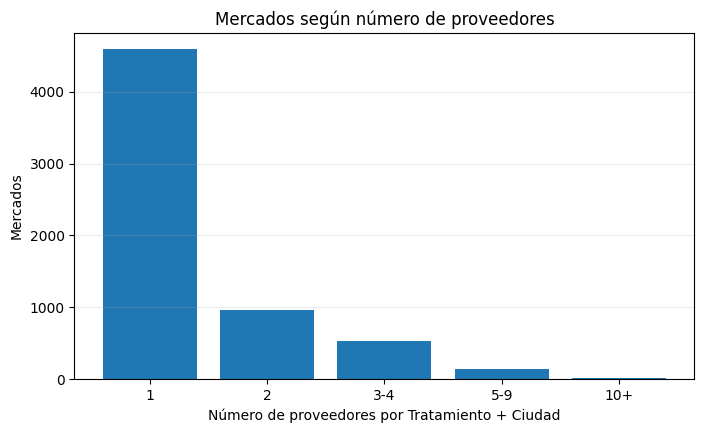

In [6]:
# Distribución no solapada para visualización.
mercados["RANGO_PROVEEDORES"] = pd.cut(
    mercados["PROVEEDORES"],
    bins=[0, 1, 2, 4, 9, np.inf],
    labels=["1", "2", "3-4", "5-9", "10+"]
)

dist_mercados = (
    mercados.groupby("RANGO_PROVEEDORES", observed=True)
    .size()
    .reindex(["1", "2", "3-4", "5-9", "10+"])
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(dist_mercados.index.astype(str), dist_mercados.values)
ax.set_title("Mercados según número de proveedores")
ax.set_xlabel("Número de proveedores por Tratamiento + Ciudad")
ax.set_ylabel("Mercados")
ax.grid(axis="y", alpha=0.25)
plt.show()

### Hallazgo clave

De **6.246 mercados Tratamiento + Ciudad**:

- **73,52 %** dispone de un único proveedor.
- Solo **26,48 %** dispone de dos o más proveedores.
- **11,06 %** dispone de tres o más.
- Solo **2,50 %** dispone de cinco o más.

Por tanto, **no todo el histórico representa un espacio real de optimización de proveedores**. El primer filtro estratégico es la existencia de alternativas dentro del mismo tratamiento y ciudad.

## 5. ¿Dónde están el volumen y el gasto?

In [7]:
mercados["TIPO_MERCADO"] = np.where(
    mercados["PROVEEDORES"] >= 2,
    "2 o más proveedores",
    "1 proveedor"
)

resumen_tipo_mercado = (
    mercados.groupby("TIPO_MERCADO")
    .agg(
        MERCADOS=("CODIGO_TRATAMIENTO", "size"),
        SERVICIOS=("SERVICIOS", "sum"),
        GASTO=("GASTO_TOTAL", "sum")
    )
    .reset_index()
)

for col in ["MERCADOS", "SERVICIOS", "GASTO"]:
    resumen_tipo_mercado[f"PCT_{col}"] = (
        resumen_tipo_mercado[col] / resumen_tipo_mercado[col].sum() * 100
    )

display(resumen_tipo_mercado)

,TIPO_MERCADO,MERCADOS,SERVICIOS,GASTO,PCT_MERCADOS,PCT_SERVICIOS,PCT_GASTO
0,1 proveedor,4592,25757,"7,444,541.31",73.52,35.58,39.89
1,2 o más proveedores,1654,46633,"11,217,075.09",26.48,64.42,60.11


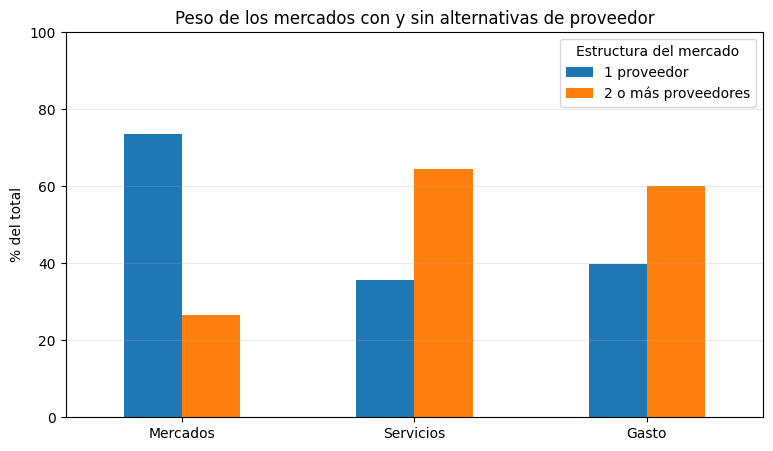

In [8]:
grafico = resumen_tipo_mercado.set_index("TIPO_MERCADO")[
    ["PCT_MERCADOS", "PCT_SERVICIOS", "PCT_GASTO"]
].T

grafico.index = ["Mercados", "Servicios", "Gasto"]

ax = grafico.plot(kind="bar", figsize=(9, 5))
ax.set_title("Peso de los mercados con y sin alternativas de proveedor")
ax.set_ylabel("% del total")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Estructura del mercado")
plt.xticks(rotation=0)
plt.show()

### Hallazgo clave: la oportunidad está concentrada

Aunque los mercados con **2 o más proveedores representan solo el 26,48 %**, concentran:

- **64,42 % de los servicios**.
- **60,11 % del gasto histórico**.

Esto justifica focalizar el esfuerzo analítico: una fracción relativamente pequeña de mercados concentra la mayoría del volumen y del gasto donde existe capacidad de elección.

**Precaución:** el 60,11 % del gasto **no es ahorro potencial**. Solo es gasto histórico ocurrido en mercados con alternativas. El ahorro real se calculará posteriormente con precios vigentes y restricciones operativas.

## 6. Dispersión histórica de costes entre proveedores comparables

In [9]:
costos_proveedor = (
    df.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "DESCPROCED",
            "CODIGO_MUNICIPIO",
            "DESCMUNICIPIO",
            "CODPROVEEDOR",
            "NOMBREPROVEEDOR"
        ]
    )
    .agg(
        SERVICIOS=("IDEPREADMIN", "size"),
        GASTO_TOTAL=("SUMA", "sum"),
        COSTO_PROMEDIO=("SUMA", "mean"),
        COSTO_MEDIANA=("SUMA", "median"),
        COSTO_MIN=("SUMA", "min"),
        COSTO_MAX=("SUMA", "max"),
        DESV_COSTO=("SUMA", "std")
    )
    .reset_index()
)

dispersion_precios = (
    costos_proveedor.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "DESCPROCED",
            "CODIGO_MUNICIPIO",
            "DESCMUNICIPIO"
        ]
    )
    .agg(
        PROVEEDORES=("CODPROVEEDOR", "nunique"),
        SERVICIOS=("SERVICIOS", "sum"),
        GASTO_TOTAL=("GASTO_TOTAL", "sum"),
        COSTO_PROV_MIN=("COSTO_MEDIANA", "min"),
        COSTO_PROV_MEDIANA=("COSTO_MEDIANA", "median"),
        COSTO_PROV_MAX=("COSTO_MEDIANA", "max")
    )
    .reset_index()
)

dispersion_precios = dispersion_precios[
    dispersion_precios["PROVEEDORES"] >= 2
].copy()

dispersion_precios["BRECHA_COSTO"] = (
    dispersion_precios["COSTO_PROV_MAX"] -
    dispersion_precios["COSTO_PROV_MIN"]
)

dispersion_precios["BRECHA_PCT"] = np.where(
    dispersion_precios["COSTO_PROV_MIN"] > 0,
    (
        dispersion_precios["COSTO_PROV_MAX"] /
        dispersion_precios["COSTO_PROV_MIN"] - 1
    ) * 100,
    np.nan
)

print(f"Combinaciones Tratamiento-Ciudad-Proveedor: {len(costos_proveedor):,}")
print(f"Mercados competitivos analizados: {len(dispersion_precios):,}")

display(
    dispersion_precios["BRECHA_PCT"].describe(
        percentiles=[.10, .25, .50, .75, .90, .95, .99]
    ).to_frame("BRECHA_PCT")
)

Combinaciones Tratamiento-Ciudad-Proveedor: 9,269
Mercados competitivos analizados: 1,654


,BRECHA_PCT
count,"1,654.00"
mean,559.13
std,"3,631.13"
min,0.00
10%,2.88
25%,15.49
50%,48.85
75%,130.18
90%,284.01
95%,703.12


### Resultado inicial

En los **1.654 mercados competitivos**, la brecha histórica entre el proveedor con menor y mayor mediana de coste presenta:

- **Mediana: 48,85 %**
- **P90: 284,01 %**

La señal económica es relevante, pero existe una limitación: muchas combinaciones proveedor–mercado tienen muy pocas observaciones. Por ello se realiza una prueba adicional de robustez.

## 7. Evidencia histórica por proveedor

,NIVEL_EVIDENCIA,COMBINACIONES_PROVEEDOR,SERVICIOS,GASTO
0,1-2 servicios,5487,6813,"8,573,595.42"
1,3-4 servicios,1164,3959,"1,837,035.83"
2,5-9 servicios,1146,7555,"2,532,772.52"
3,10+ servicios,1472,54063,"5,718,212.63"


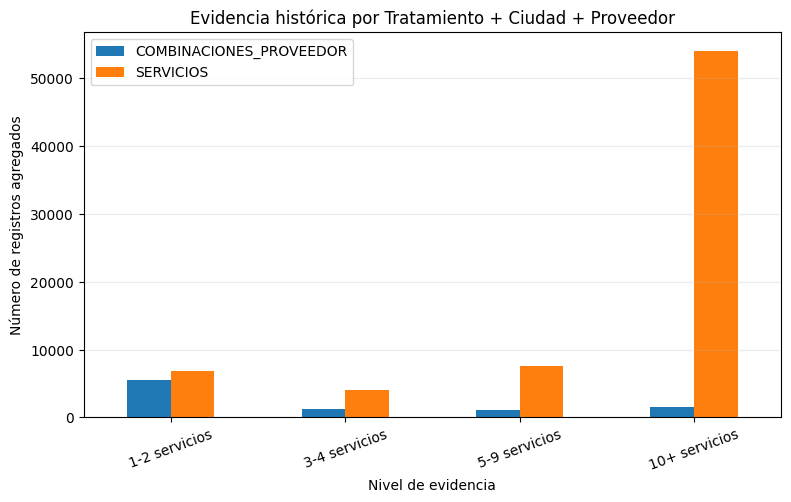

In [10]:
costos_proveedor["NIVEL_EVIDENCIA"] = pd.cut(
    costos_proveedor["SERVICIOS"],
    bins=[0, 2, 4, 9, np.inf],
    labels=[
        "1-2 servicios",
        "3-4 servicios",
        "5-9 servicios",
        "10+ servicios"
    ]
)

resumen_evidencia = (
    costos_proveedor.groupby("NIVEL_EVIDENCIA", observed=True)
    .agg(
        COMBINACIONES_PROVEEDOR=("CODPROVEEDOR", "size"),
        SERVICIOS=("SERVICIOS", "sum"),
        GASTO=("GASTO_TOTAL", "sum")
    )
    .reset_index()
)

display(resumen_evidencia)

ax = resumen_evidencia.set_index("NIVEL_EVIDENCIA")[
    ["COMBINACIONES_PROVEEDOR", "SERVICIOS"]
].plot(kind="bar", figsize=(9, 5))

ax.set_title("Evidencia histórica por Tratamiento + Ciudad + Proveedor")
ax.set_xlabel("Nivel de evidencia")
ax.set_ylabel("Número de registros agregados")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20)
plt.show()

### Hallazgo

**5.487 de 9.269 combinaciones Tratamiento + Ciudad + Proveedor (~59 %) tienen solo 1 o 2 servicios históricos.**

Esto impide interpretar automáticamente una diferencia de mediana histórica como una diferencia estructural de precio. En la decisión operativa futura, el **baremo vigente** será más fiable que una mediana basada en muy pocas prestaciones.

## 8. Prueba de robustez: proveedores con al menos 5 servicios

In [11]:
costos_proveedor_robusto = costos_proveedor[
    costos_proveedor["SERVICIOS"] >= 5
].copy()

dispersion_robusta = (
    costos_proveedor_robusto.groupby(
        [
            "CODIGO_TRATAMIENTO",
            "DESCPROCED",
            "CODIGO_MUNICIPIO",
            "DESCMUNICIPIO"
        ]
    )
    .agg(
        PROVEEDORES_VALIDOS=("CODPROVEEDOR", "nunique"),
        SERVICIOS=("SERVICIOS", "sum"),
        GASTO_TOTAL=("GASTO_TOTAL", "sum"),
        COSTO_MIN=("COSTO_MEDIANA", "min"),
        COSTO_MEDIANA=("COSTO_MEDIANA", "median"),
        COSTO_MAX=("COSTO_MEDIANA", "max")
    )
    .reset_index()
)

dispersion_robusta = dispersion_robusta[
    dispersion_robusta["PROVEEDORES_VALIDOS"] >= 2
].copy()

dispersion_robusta["BRECHA_PCT"] = (
    dispersion_robusta["COSTO_MAX"] /
    dispersion_robusta["COSTO_MIN"] - 1
) * 100

comparacion_brechas = pd.DataFrame({
    "MUESTRA": ["Todos los proveedores", "Proveedores con >=5 servicios"],
    "MERCADOS": [len(dispersion_precios), len(dispersion_robusta)],
    "MEDIANA_BRECHA_PCT": [
        dispersion_precios["BRECHA_PCT"].median(),
        dispersion_robusta["BRECHA_PCT"].median()
    ],
    "P90_BRECHA_PCT": [
        dispersion_precios["BRECHA_PCT"].quantile(.90),
        dispersion_robusta["BRECHA_PCT"].quantile(.90)
    ]
})

display(comparacion_brechas)

,MUESTRA,MERCADOS,MEDIANA_BRECHA_PCT,P90_BRECHA_PCT
0,Todos los proveedores,1654,48.85,284.01
1,Proveedores con >=5 servicios,416,30.22,139.62


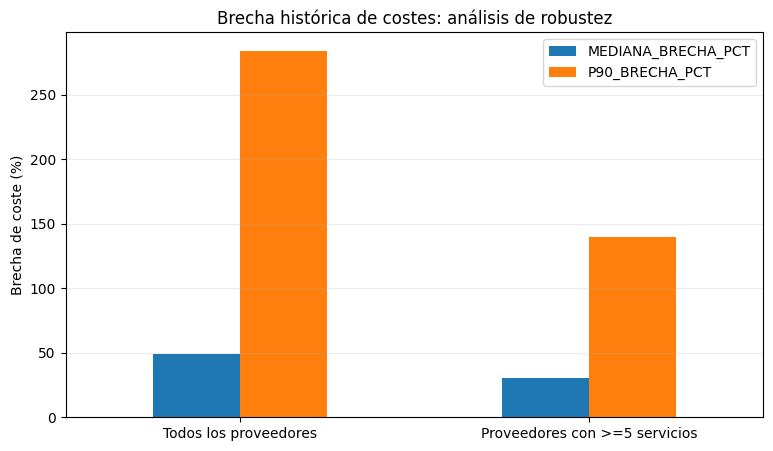

In [12]:
grafico_brechas = comparacion_brechas.set_index("MUESTRA")[
    ["MEDIANA_BRECHA_PCT", "P90_BRECHA_PCT"]
]

ax = grafico_brechas.plot(kind="bar", figsize=(9, 5))
ax.set_title("Brecha histórica de costes: análisis de robustez")
ax.set_ylabel("Brecha de coste (%)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.show()

### Resultado de robustez

Al exigir al menos **5 servicios históricos por proveedor**:

- Los mercados comparables pasan de **1.654 a 416**.
- La brecha mediana baja de **48,85 % a 30,22 %**.
- El P90 baja de **284,01 % a 139,62 %**.

La reducción confirma que la baja frecuencia inflaba parte de las diferencias, pero **la señal económica permanece material** incluso cuando se exige evidencia mínima.

El umbral de 5 servicios se utiliza aquí como **prueba diagnóstica**, no como regla definitiva de elegibilidad.

## 9. Cobertura de los mercados robustos

In [13]:
mercados_robustos = dispersion_robusta[
    ["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"]
].drop_duplicates()

df_robusto = df.merge(
    mercados_robustos,
    on=["CODIGO_TRATAMIENTO", "CODIGO_MUNICIPIO"],
    how="inner"
)

cobertura_robusta = pd.DataFrame({
    "INDICADOR": ["Servicios", "Gasto"],
    "TOTAL": [len(df), df["SUMA"].sum()],
    "MERCADOS_ROBUSTOS": [len(df_robusto), df_robusto["SUMA"].sum()]
})

cobertura_robusta["PCT_COBERTURA"] = (
    cobertura_robusta["MERCADOS_ROBUSTOS"] /
    cobertura_robusta["TOTAL"] * 100
)

display(cobertura_robusta)

,INDICADOR,TOTAL,MERCADOS_ROBUSTOS,PCT_COBERTURA
0,Servicios,"72,390.00","32,109.00",44.36
1,Gasto,"18,661,616.40","3,720,595.89",19.94


### Lectura

Los 416 mercados robustos concentran:

- **44,36 % del volumen total de servicios**.
- **19,94 % del gasto total**.

Esto revela dos realidades de negocio diferentes:

1. **Alto volumen / buena evidencia:** adecuado para forecast de demanda, análisis de utilización y optimización.
2. **Bajo volumen / alto coste:** el histórico es insuficiente para un forecast específico fiable; la decisión deberá apoyarse principalmente en baremo actual, calidad, capacidad y reglas de negocio.

Esta diferencia es una de las razones para **no aplicar ML indiscriminadamente a todos los datos**.

# Conclusiones del EDA de negocio

El análisis permite construir el primer filtro estratégico del proyecto:

1. El histórico válido contiene **72.390 servicios**, **297 proveedores**, **705 tratamientos** y **67 municipios**.
2. La unidad correcta de competencia es **Tratamiento + Ciudad**.
3. Existen **6.246 mercados**, pero **73,52 %** tienen un único proveedor y, por tanto, capacidad de optimización muy limitada.
4. Los **1.654 mercados con dos o más proveedores** representan solo **26,48 % de los mercados**, pero concentran **64,42 % del volumen** y **60,11 % del gasto**.
5. Existen diferencias históricas relevantes de coste entre proveedores comparables.
6. Parte de esas diferencias está inflada por baja evidencia, pero la señal permanece: en mercados con al menos dos proveedores y ≥5 servicios por proveedor, la brecha mediana sigue siendo **30,22 %**.
7. Los mercados frecuentes y los mercados de baja frecuencia/alto coste requieren estrategias diferentes.

## Decisión metodológica

El siguiente paso no será aplicar ML a todo el histórico. Primero se segmentarán los **mercados con competencia** para identificar dónde existe simultáneamente:

- volumen suficiente;
- alternativas de proveedor;
- evidencia histórica;
- diferencias económicas;
- y una oportunidad real de optimización.

➡️ **Siguiente notebook: `02_Segmentacion_Clustering.ipynb`**